In [1]:
import anndata as ad
import scanpy as sc
import hdf5plugin
import scipy
from scipy import stats, sparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

In [45]:
pd.read_csv("Data/SimulResults_Ising/Keggoro_abcd/1/Keggoro_abcd_async_StateCounts_Main.csv")

,State,Fraction,Replicate,Mode
0,0010010101000000000010111101010111111100010110...,0.000015,1,Async
1,0010010111000000000010111101010111111100010110...,0.000015,1,Async
2,1110001001101101101110100000011000001100111100...,0.000015,1,Async
3,1110001011101101101110100000011000001100111100...,0.000015,1,Async
4,1101101101101011000101111101001111001011001010...,0.000015,1,Async
...,...,...,...,...
65531,1011111010010111110011000101100111001111001000...,0.000015,1,Async
65532,1011111010010111110011000101100111001111001100...,0.000015,1,Async
65533,1000011110010001011000011000110000001000111110...,0.000015,1,Async
65534,1000011110010001011000011000110000001000111110...,0.000015,1,Async


# Compare Pseq Datasets:

In [3]:
exp_data_list = []
for dataset in ["AdamsonWeissman2016_GSM2406681_10X010","NormanWeissman2019_filtered","ReplogleWeissman2022_K562_essential"]:
    dataset = sc.read_h5ad(f"Data/Experimental/{dataset}/perturb_subset_Keggoro_abcd.h5ad")
    exp_data_list.append(dataset[dataset.obs["perturbation"]=="ctrl"])

exp_data_list[0].layers["log1p"] = exp_data_list[0].layers["log1p"].tocsc()

/tmp/ipykernel_271785/1359795984.py:6: ImplicitModificationWarning: Setting element `.layers['log1p']` of view, initializing view as actual.
  exp_data_list[0].layers["log1p"] = exp_data_list[0].layers["log1p"].tocsc()


In [3]:
cos = []
for i in range(3):
    for j in range(i+1,3):
        common_genes = list(set(exp_data_list[i].var_names) & set(exp_data_list[j].var_names))
        cos.append(cosine_similarity(X=np.asarray(exp_data_list[i][:,common_genes].var["log1p_mean_counts"]).reshape(1, -1),Y=np.asarray(exp_data_list[j][:,common_genes].var["log1p_mean_counts"]).reshape(1, -1)))
print(cos)
# Among the HVGs of the control cells, the cosine similarity is quite high (~95%), meaning that they should be comparable

[array([[0.94589484]], dtype=float32), array([[0.94499695]], dtype=float32), array([[0.9603218]], dtype=float32)]


# Examine discretization of Racipe:

In [4]:
exp_data_list[0].layers["log1p"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7262443 stored elements and shape (6904, 5000)>

In [5]:
exp_data_list[0].layers["discretizer"] = exp_data_list[0].layers["log1p"].copy()
exp_data_list[0].layers["discretizer"] /= np.max(exp_data_list[0].layers["log1p"])

/tmp/ipykernel_240115/3599195062.py:1: ImplicitModificationWarning: Setting element `.layers['discretizer']` of view, initializing view as actual.
  exp_data_list[0].layers["discretizer"] = exp_data_list[0].layers["log1p"].copy()


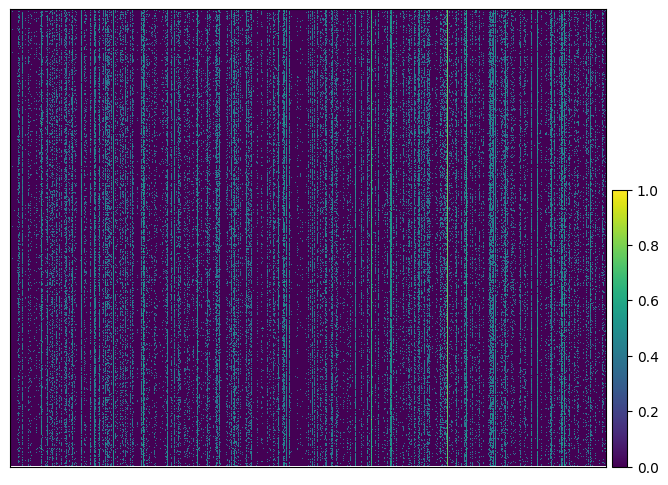

In [6]:
sc.pl.heatmap(exp_data_list[0],var_names=exp_data_list[0].var_names,groupby="perturbation",layer="discretizer")

In [7]:
discretizer_test = pd.DataFrame((exp_data_list[0].layers["log1p"]/np.max(exp_data_list[0].layers["log1p"])).todense(),columns=exp_data_list[0].var_names)

In [ ]:
from grins import racipe_run as racipe
lvl_df_state = racipe.discretise_solutions(discretizer_test)
lvl_df_state
sol_matrix = ad.AnnData(sparse.csc_matrix(np.asarray([list(string[1:-1]) for string in lvl_df_state.values],dtype=int)))
scipy.sparse.csr_matrix.getnnz(sol_matrix.X)/(sol_matrix.X.shape[0]*sol_matrix.X.shape[1]) # Only .2% are ON

In [85]:
np.histogram(exp_data_list[0].layers["log1p"].todense()[:100,5],bins=20,range=(0,10))[0]

array([100,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0])

## Try plotting densities, not working:

In [173]:
data_array2 = np.array([np.histogram(exp_data_list[0].layers["log1p"].todense()[:,i],bins=30,range=(0,10))[0] for i in range(10)])

data_array = np.array([ [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            [6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
            [11, 12, 13, 14, 15, 16, 17, 18 , 19, 20],
            [16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
            [21, 22, 23, 24, 25, 26, 27, 28, 29, 30] ])
            
        

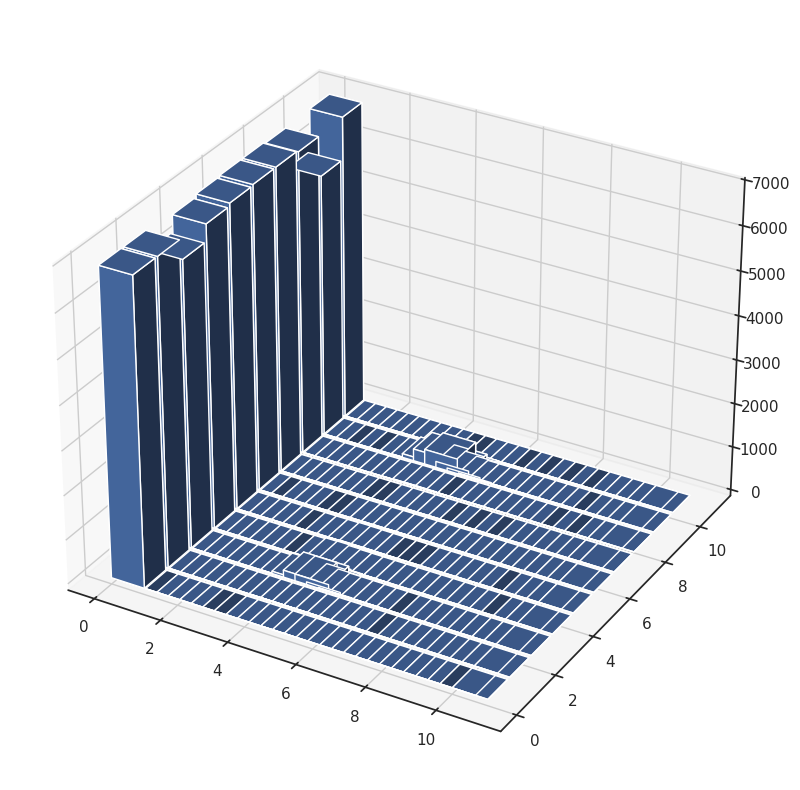

In [174]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
#
# Create an X-Y mesh of the same dimension as the 2D data. You can
# think of this as the floor of the plot.
#
x_data, y_data = np.meshgrid( np.linspace(0,10,data_array2.shape[1]),
                              np.linspace(0,10,data_array2.shape[0]) )
#
# Flatten out the arrays so that they may be passed to "ax.bar3d".
# Basically, ax.bar3d expects three one-dimensional arrays:
# x_data, y_data, z_data. The following call boils down to picking
# one entry from each array and plotting a bar to from
# (x_data[i], y_data[i], 0) to (x_data[i], y_data[i], z_data[i]).
#
x_data = x_data.flatten()
y_data = y_data.flatten()
z_data = data_array2.flatten()
ax.bar3d( x_data,
          y_data,
          np.zeros(len(z_data)),
          1, 1, z_data )
#
# Finally, display the plot.
#
plt.show()

In [175]:
x = np.array([np.histogram(exp_data_list[0].layers["log1p"].todense()[:,i],bins=30,range=(0,10))[0] for i in range(10)]).flatten()

KeyboardInterrupt: 

In [ ]:
x = np.array([exp_data_list[0].layers["log1p"].todense()[:,i] for i in range(10)]).flatten()

In [ ]:
x

array([0., 0., 0., ..., 0., 0., 0.], shape=(69040,), dtype=float32)

In [ ]:
label = np.asarray([[str(i)]*6904 for i in range(10)]).flatten()

In [ ]:
df = pd.DataFrame({"x":x,"label":label})

In [ ]:
df[df["label"]=="8"]

,x,label
55232,4.734358,8
55233,0.000000,8
55234,5.890594,8
55235,0.000000,8
55236,0.000000,8
...,...,...
62131,0.000000,8
62132,3.995557,8
62133,0.000000,8
62134,0.000000,8


<Axes: ylabel='Density'>

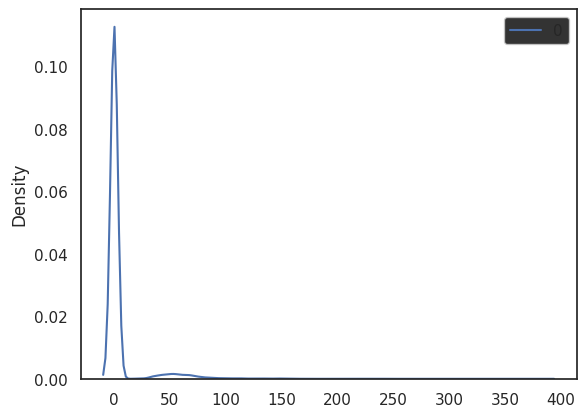

In [193]:
sns.kdeplot(data=exp_data_list[0].X.todense()[:,32])

/storage/mi/sommereg03/vbsc/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/storage/mi/sommereg03/vbsc/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/storage/mi/sommereg03/vbsc/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/storage/mi/sommereg03/vbsc/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/storage/

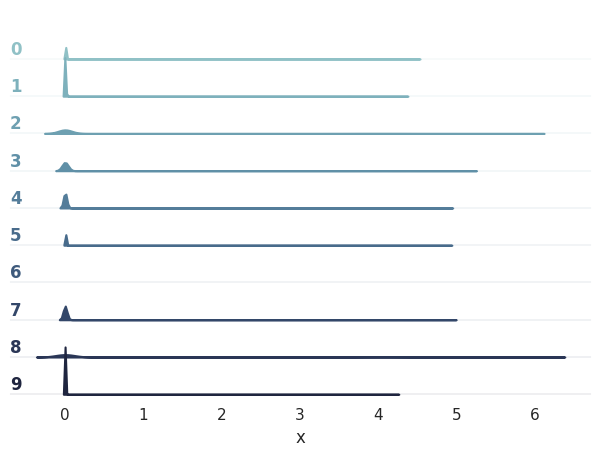

In [ ]:
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(df, row="label", hue="label", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "x",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
#g.map(sns.kdeplot, "x", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=0.1, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "x")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

In [ ]:
adamson_data = sc.read_h5ad(f"Data/AdamsonWeissman2016_GSM2406681_10X010/perturb_norm.h5ad")
norman_data = sc.read_h5ad(f"Data/NormanWeissman2019_filtered/perturb_norm.h5ad")
adamson_data.layers["log1p"] = adamson_data.layers["log1p"].tocsc()
adamson_data = adamson_data[adamson_data.obs["perturbation"]=="ctrl"]
norman_data = norman_data[norman_data.obs["perturbation"]=="ctrl"]

topo = "dorothea_tf2_abc"
replicate = "001"
path_to_data = f"Data/SimulResults_Racipe/{topo}/{replicate}/{topo}_steadystate_solutions_{replicate}"
grins_data = sc.read_h5ad(f"{path_to_data}.h5ad")
grins_data.layers["log1p"] = grins_data.layers["log1p"].tocsc()

In [ ]:
# Filter out very low GRiNS steady state values as dropouts:
grins_data.var

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
AHR,862922,0.366708,0.312405,13.7078,3.667084e+05,12.812325
AR,827605,27.340544,3.344293,17.2395,2.734054e+07,17.123882
ARID2,1000000,127.963882,4.859532,0.0000,1.279639e+08,18.667259
ARID3A,915541,1.835570,1.042243,8.4459,1.835570e+06,14.422867
ARNT,1000000,8.394449,2.240119,0.0000,8.394449e+06,15.943081
...,...,...,...,...,...,...
ZNF263,968527,7.181237,2.101843,3.1473,7.181237e+06,15.786983
ZNF274,1000000,126.606216,4.848949,0.0000,1.266062e+08,18.656591
ZNF384,1000000,125.337738,4.838959,0.0000,1.253377e+08,18.646523
ZNF639,1000000,129.138596,4.868600,0.0000,1.291386e+08,18.676397


# Get parameters of normal dists of non-zero log1pexpr for genes:

In [4]:
non_zero_entries = np.split(exp_data_list[1].layers["log1p"].tocsc().indices,exp_data_list[1].layers["log1p"].tocsc().indptr[1:-1])
non_zero_vals = [exp_data_list[1].layers["log1p"][non_zero_entries[i],i].todense().T for i in range(len(non_zero_entries))]
nz_cc = np.concat(non_zero_vals,axis=1)

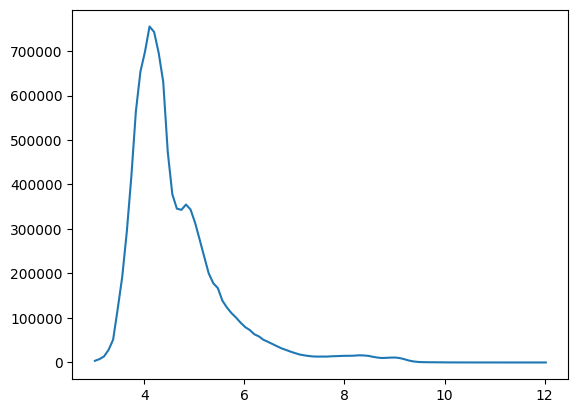

In [5]:
testhist = np.histogram(nz_cc,bins=100)
plt.plot(testhist[1][:-1],testhist[0])
# Mixed Gaussian may be possible?

In [12]:
non_zero_means = [8 if np.isnan(np.mean(nz_gene)) else np.mean(nz_gene) for nz_gene in non_zero_vals]
non_zero_vars = [8 if np.isnan(np.var(nz_gene)) else np.var(nz_gene) for nz_gene in non_zero_vals]

/storage/mi/sommereg03/vbsc/lib/python3.13/site-packages/numpy/matrixlib/defmatrix.py:451: RuntimeWarning: Mean of empty slice.
  return N.ndarray.mean(self, axis, dtype, out, keepdims=True)._collapse(axis)
/storage/mi/sommereg03/vbsc/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/storage/mi/sommereg03/vbsc/lib/python3.13/site-packages/numpy/matrixlib/defmatrix.py:519: RuntimeWarning: Degrees of freedom <= 0 for slice
  return N.ndarray.var(self, axis, dtype, out, ddof, keepdims=True)._collapse(axis)
/storage/mi/sommereg03/vbsc/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/storage/mi/sommereg03/vbsc/lib/python3.13/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


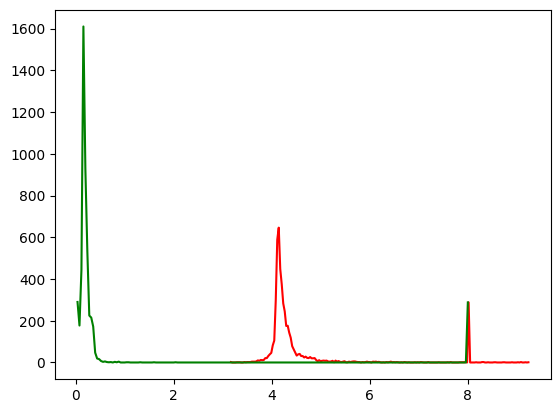

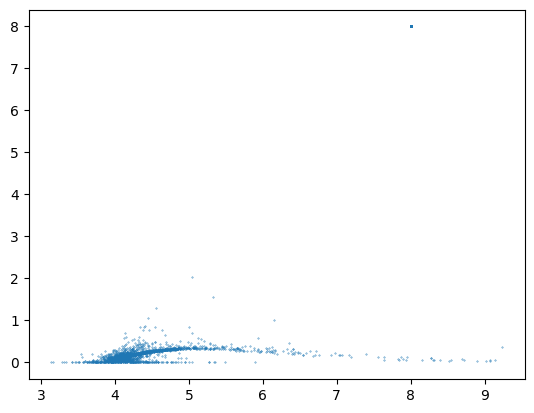

In [40]:
meanhist = np.histogram(non_zero_means,bins=200)
varhist = np.histogram(non_zero_vars,bins=200)
plt.plot(meanhist[1][1:],meanhist[0],c="red")
plt.plot(varhist[1][1:],varhist[0],c="green")
# There are no almost-zero means (or values for that matter) -> maybe not exponential distribution for dropouts, but just simply setting them to zero
plt.show()
plt.scatter(non_zero_means,non_zero_vars,s=0.1)
# There are no almost-zero means (or values for that matter) -> maybe not exponential distribution for dropouts, but just simply setting them to zero
plt.show()

## Get parameters for cells:

In [24]:
len(cell_non_zero_entries[5])

963

In [ ]:
dataset = exp_data_list[1].layers["log1p"].tocsr()
cell_non_zero_entries = np.split(dataset.indices,dataset.indptr[1:-1])
cell_non_zero_vals = [dataset[i,cell_non_zero_entries[i]].todense() for i in range(len(cell_non_zero_entries))]
cnz_cc = np.concat(cell_non_zero_vals,axis=1)

In [32]:
cell_non_zero_means = [35 if np.isnan(np.mean(nz_gene)) else np.mean(nz_gene) for nz_gene in cell_non_zero_vals]
cell_non_zero_vars = [35 if np.isnan(np.var(nz_gene)) else np.var(nz_gene) for nz_gene in cell_non_zero_vals]

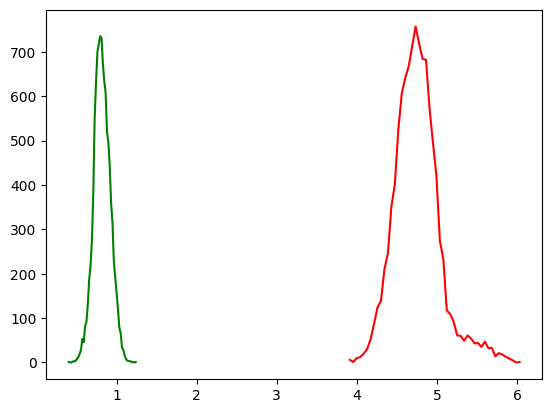

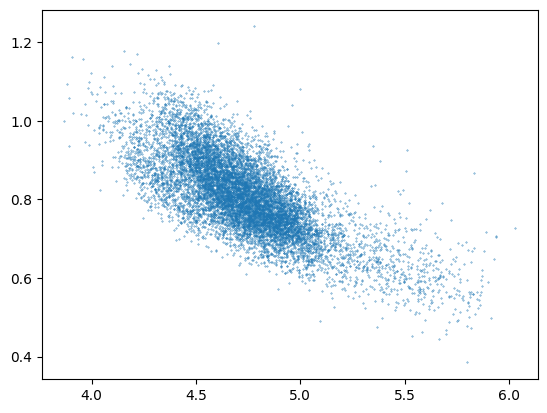

In [42]:
cmeanhist = np.histogram(cell_non_zero_means,bins=50)
cvarhist = np.histogram(cell_non_zero_vars,bins=50)
plt.plot(cmeanhist[1][1:],cmeanhist[0],c="red")
plt.plot(cvarhist[1][1:],cvarhist[0],c="green")
plt.show()
plt.scatter(cell_non_zero_means,cell_non_zero_vars,s=0.1)
plt.show()

In [27]:
pd.read_parquet("Data/SimulResults_Ising/Keggoro_abcd_4096/1/Keggoro_abcd_async_ising_results.parquet")

,Step,Initnum,A2M|A2ML1|AAK1|AATBC|AATK|ABALON|ABAT|ABCA1,ABCA10|ABCA13|ABCA2|ABCA4|ABCA5|ABCA7|ABCA9|ABCB1,ABCB10|ABCB11|ABCB4|ABCB6|ABCB8|ABCB9|ABCC1|ABCC2,ABCC3|ABCC4|ABCC5|ABCC6|ABCC8|ABCC9|ABCD1|ABCE1,ABCG1|ABCG2|ABCG5|ABCG8|ABHD11|ABHD12|ABHD16B|ABHD2,ABHD5|ABI2|ABL1|ABLIM1|ABLIM2|ABLIM3|ABR|ABT1,ABTB2|AC000067.1|AC000068.5|AC000111.3|AC002066.1|AC002116.7|AC002127.4|AC002386.1,AC002480.2|AC002480.4|AC003006.7|AC003090.1|AC003092.2|AC003682.16|AC004069.2|AC005162.5,...,ZNF670|ZNF678|ZNF680|ZNF687|ZNF689|ZNF691|ZNF692|ZNF7,ZNF710|ZNF713|ZNF721|ZNF740|ZNF746|ZNF749|ZNF750|ZNF75A,ZNF76|ZNF763|ZNF764|ZNF766|ZNF768|ZNF77|ZNF773|ZNF775,ZNF776|ZNF777|ZNF778|ZNF782|ZNF786|ZNF787|ZNF79|ZNF790,ZNF792|ZNF8|ZNF804B|ZNF81|ZNF814|ZNF821|ZNF827|ZNF83,ZNF831|ZNF837|ZNF839|ZNF84|ZNF841|ZNF850|ZNF860|ZNF878,ZNF879|ZNF883|ZNF92|ZNF93|ZNFX1|ZNHIT2|ZNRF1|ZNRF3,ZNRF4|ZP3|ZPBP2|ZPLD1|ZRANB2|ZRANB3|ZSCAN10|ZSCAN18,ZSCAN2|ZSCAN20|ZSCAN22|ZSCAN25|ZSCAN31|ZSCAN9|ZSWIM3|ZSWIM4,ZSWIM5|ZXDC|ZYX|ZZEF1|ZZZ3
0,0,0,51,100,242,222,91,161,221,158,...,99,225,250,96,96,43,187,132,22,140
1,29314,0,51,100,242,222,91,177,221,158,...,99,233,250,96,96,171,191,4,22,156
2,0,1,204,155,13,33,164,94,34,97,...,156,30,5,159,159,212,68,123,233,112
3,29314,1,140,155,13,33,164,94,34,97,...,156,31,77,159,159,212,84,123,233,116
4,0,2,245,157,160,244,99,133,185,37,...,198,129,72,43,76,38,202,181,72,140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8187,29314,4093,152,142,155,210,55,154,223,92,...,76,255,253,222,178,192,220,46,164,20
8188,0,4094,225,136,54,7,240,65,68,24,...,22,96,176,106,97,178,82,96,5,252
8189,29314,4094,161,136,54,7,240,81,68,24,...,22,105,248,106,97,178,86,96,5,252
8190,0,4095,158,119,201,248,15,190,187,231,...,233,159,79,149,158,77,173,159,250,0


# Plot Counts:

## Norman:

In [6]:
norman_mean = np.asarray(norman_data.layers["log1p"].mean(axis=0)).squeeze()
n_squared = norman_data.layers["log1p"].multiply(norman_data.layers["log1p"])
norman_var = np.asarray(np.mean(n_squared,axis=0)).squeeze()-norman_mean*norman_mean

r_norman_mean = np.asarray(norman_data.X.mean(axis=0)).squeeze()
r_n_squared = norman_data.X.multiply(norman_data.X)
r_norman_var = np.asarray(np.mean(r_n_squared,axis=0)).squeeze()-r_norman_mean*r_norman_mean

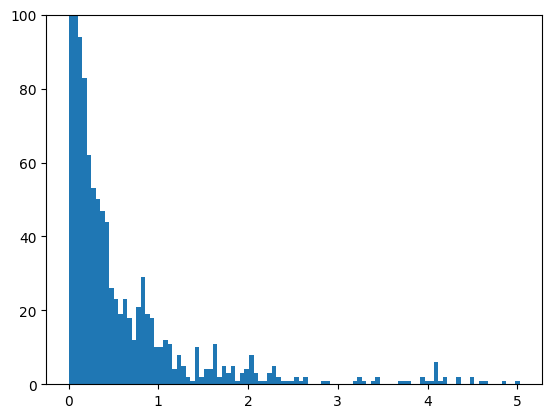

In [7]:
plt.hist(norman_mean,bins=100)
plt.ylim(0,100)
plt.show()

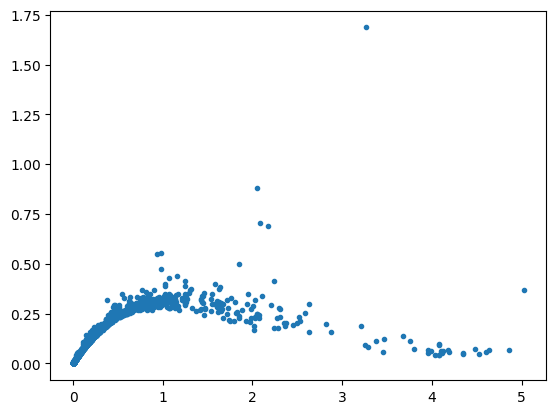

/tmp/ipykernel_72305/3989386553.py:3: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(r_norman_mean),np.log(r_norman_var),".")


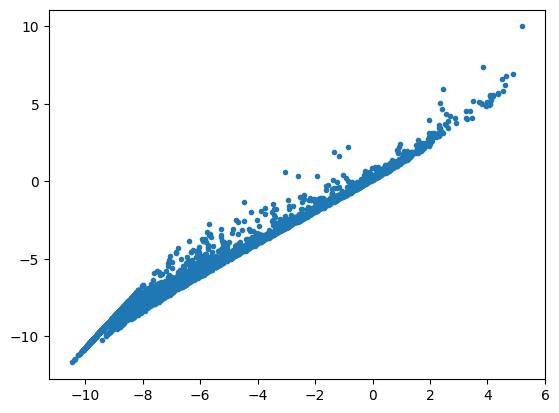

In [8]:
plt.plot(norman_mean,norman_var,".")
plt.show()
plt.plot(np.log(r_norman_mean),np.log(r_norman_var),".")
plt.show()

## GRiNS:

In [9]:
grins_mean = np.asarray(grins_data.layers["log1p"].mean(axis=0)).squeeze()
g_squared = grins_data.layers["log1p"].multiply(grins_data.layers["log1p"])
grins_var = np.asarray(np.mean(g_squared,axis=0)).squeeze()-grins_mean*grins_mean

r_grins_mean = np.asarray(grins_data.X.mean(axis=0)).squeeze()
r_g_squared = grins_data.X.multiply(grins_data.X)
r_grins_var = np.asarray(np.mean(r_g_squared,axis=0)).squeeze()-r_grins_mean*r_grins_mean

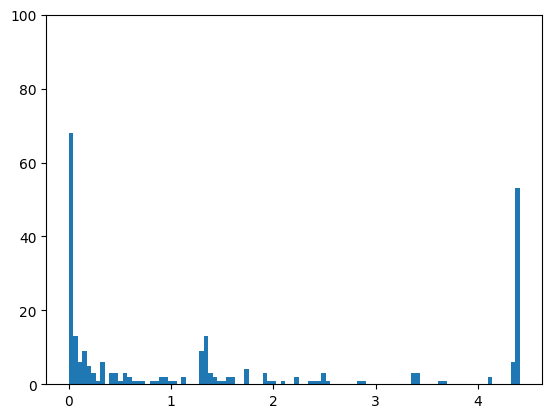

In [10]:
plt.hist(grins_mean,bins=100)
plt.ylim(0,100)
plt.show()

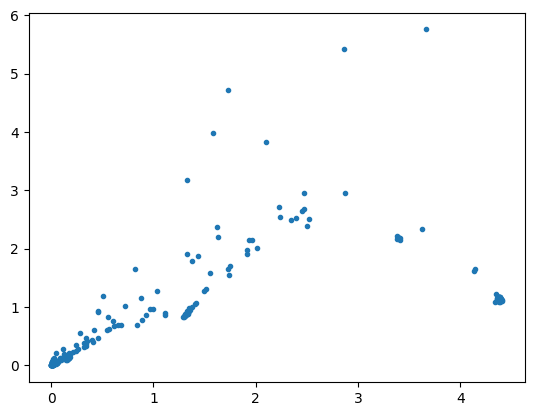

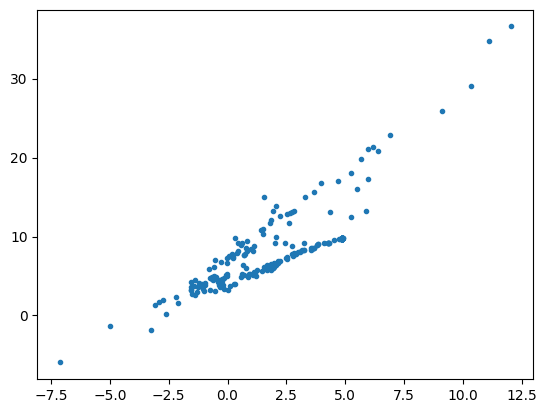

In [11]:
plt.plot(grins_mean,grins_var,".")
plt.show()
plt.plot(np.log(r_grins_mean),np.log(r_grins_var),".")
plt.show()

## Takeaway:
- Despite the smaller sample size, the data more or less looks the same for GRiNS as for Norman
- At the same time, the peak at the upper end of the GRiNS histogram is strange

# Find good metrics to predict `pct_dropout_by_counts`

## Calculate dropout stats:

In [12]:
norman_dropouts = np.asarray(norman_data.var["pct_dropout_by_counts"])
norman_mean_non_zero = np.asarray(norman_mean)/(1-norman_dropouts/100)
norman_isdropout = norman_data.var["pct_dropout_by_counts"]>99
norman_dropout_genes = list(norman_data.var[norman_isdropout].index)

In [13]:
adamson_mean = np.asarray(adamson_data.layers["log1p"].mean(axis=0)).squeeze()
adamson_dropouts = np.asarray(adamson_data.var["pct_dropout_by_counts"])
adamson_mean_non_zero = adamson_mean/(1-adamson_dropouts/100)

adamson_isdropout = adamson_data.var["pct_dropout_by_counts"]>99
adamson_dropout_genes = list(adamson_data.var[adamson_isdropout].index)

In [18]:
grins_dropouts = np.asarray(grins_data.var["pct_dropout_by_counts"])
grins_mean_non_zero = grins_mean/(1-grins_dropouts/100)
grins_isdropout = grins_data.var["pct_dropout_by_counts"]>99
grins_dropout_genes = list(grins_data.var[grins_isdropout].index)

In [ ]:
def get_nonzero_stats(layer):
    layer = layer.tocsc()
    mean_nz = []
    var_nz = []
    skew_nz = []
    median_nz = []
    non_zero_entries = np.split(layer.indices,layer.indptr[1:-1])
    for i in range(len(non_zero_entries)):
        non_zero_exprs = (layer[non_zero_entries[i],i]).todense().T
        if non_zero_exprs.shape[1] < 1:
            mean_nz.append(0)
            var_nz.append(0)
            skew_nz.append(0)
            median_nz.append(0)
            continue
        mean_nz.append(np.mean(non_zero_exprs))
        var_nz.append(np.var(non_zero_exprs))
        skew_nz.append(stats.skew(non_zero_exprs,axis=1)[0])
        median_nz.append(np.median(non_zero_exprs,axis=1)[0,0])
    mean_nz = np.asarray(mean_nz)
    var_nz = np.asarray(var_nz)
    skew_nz = np.asarray(skew_nz)
    median_nz = np.asarray(median_nz)
    return {"mean":mean_nz, "var":var_nz, "skew":skew_nz, "median":median_nz}

In [16]:
norman_stats = get_nonzero_stats(norman_data.layers["log1p"])
adamson_stats = get_nonzero_stats(adamson_data.layers["log1p"])
grins_stats = get_nonzero_stats(grins_data.layers["log1p"])

In [48]:
# Naive idea: find the percentage of non-zero cells
scipy.sparse.csr_matrix.getnnz(norman_data.X)/(norman_data.X.shape[0]*norman_data.X.shape[1])

0.09929338367154318

## Plot depending on isdropout:

### Plot dropout distribution:

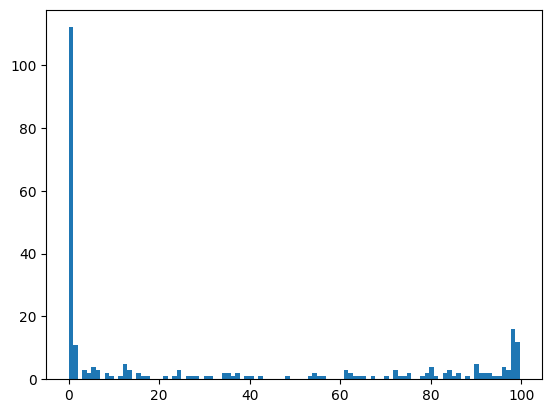

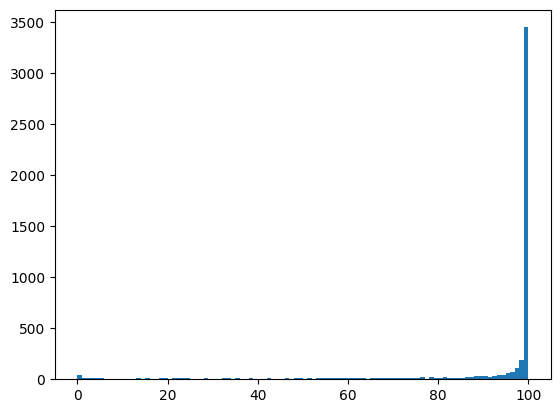

In [19]:
plt.hist(grins_data.var["pct_dropout_by_counts"],bins=100) # Most genes are not dropouts
plt.show()
plt.hist(norman_data.var["pct_dropout_by_counts"],bins=100) # Most genes are dropouts
plt.show()

In [16]:
# Use nonzero stats to classify to separate zeroes
# Look at how missingness appears across cells (e.g. cells completely missing)
# 

### Plot various axes against each other:

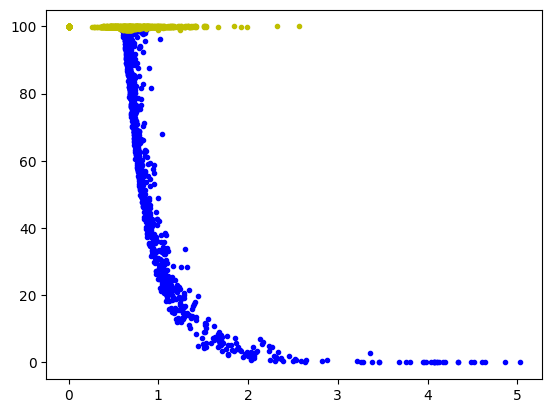

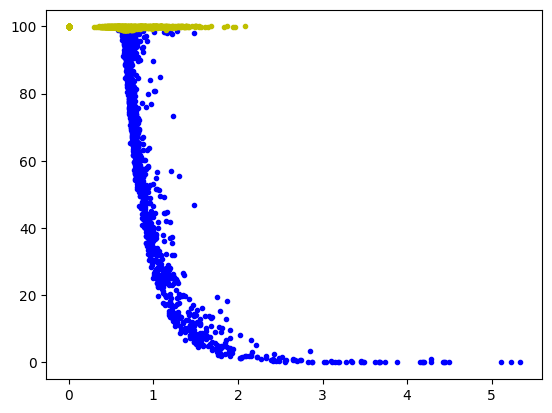

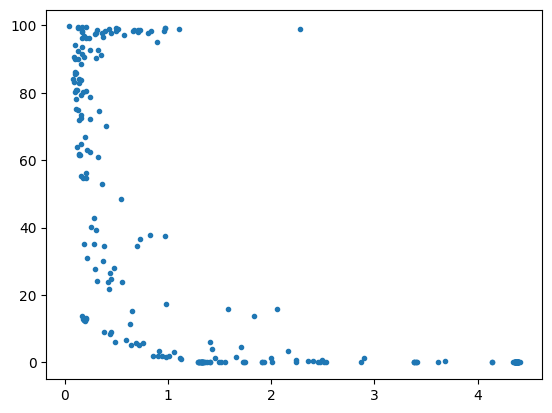

In [ ]:
plt.plot(norman_stats["mean"][~norman_isdropout],norman_dropouts[~norman_isdropout],".",c="b") # The problem with this approach is that there is no function mappable to this
plt.plot(norman_stats["mean"][norman_isdropout],norman_dropouts[norman_isdropout],".",c="y")
#plt.xlim(-1,1)
plt.show()
plt.plot(adamson_stats["mean"][~adamson_isdropout],adamson_dropouts[~adamson_isdropout],".",c="b") # The problem with this approach is that there is no function mappable to this
plt.plot(adamson_stats["mean"][adamson_isdropout],adamson_dropouts[adamson_isdropout],".",c="y") # The problem with this approach is that there is no function mappable to this
#plt.xlim(-1,1)
plt.show()
plt.plot(grins_stats["mean"],grins_dropouts,".") # The problem with this approach is that there is no function mappable to this
#plt.xlim(-1,1)
plt.show()

# These plots showcase that prob. for non 100% outliers can be modeled well with a sigmoid(?)
# Therefore, maybe mark these and find a way to distinguish them from the rest

### Takehome message:
- After designating cells with $<0.01$ expression as $0$, the nonzero_mean-pct_dropout-graph of grins looks very similar to the others

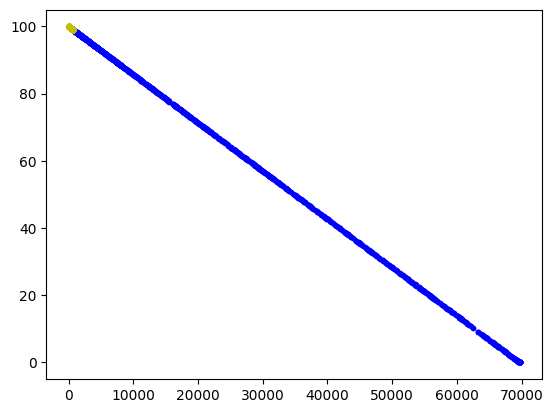

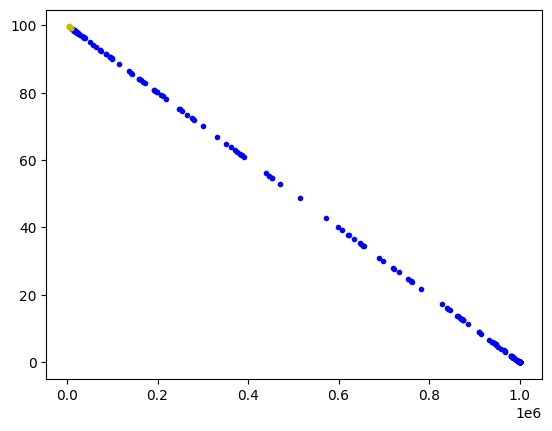

In [38]:
plt.plot(norman_data.var.n_cells_by_counts[~norman_isdropout],norman_data.var.pct_dropout_by_counts[~norman_isdropout],".",c="b") # The problem with this approach is that there is no function mappable to this
plt.plot(norman_data.var.n_cells_by_counts[norman_isdropout],norman_data.var.pct_dropout_by_counts[norman_isdropout],".",c="y")
plt.show()
plt.plot(grins_data.var.n_cells_by_counts[~grins_isdropout],grins_data.var.pct_dropout_by_counts[~grins_isdropout],".",c="b") # The problem with this approach is that there is no function mappable to this
plt.plot(grins_data.var.n_cells_by_counts[grins_isdropout],grins_data.var.pct_dropout_by_counts[grins_isdropout],".",c="y")
plt.show()

### Plot axes but for non-zero stats:

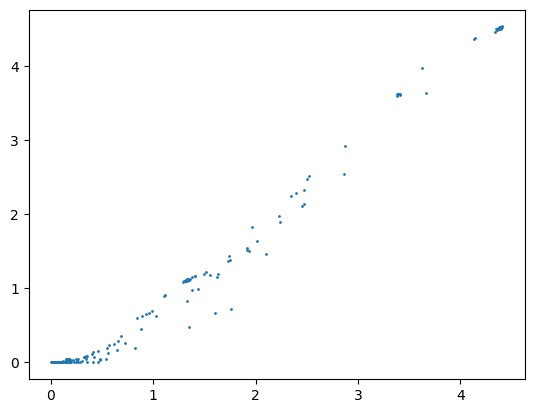

In [75]:
plt.scatter(grins_mean_nz,grins_median_nz,s=1)
#plt.xlim(0,2)
#plt.ylim(0,2)
plt.show()

In [32]:
def plot_nz_adamson_norman(xax, yax):
    s=1
    alpha=0.5

    fig, ax = plt.subplots(ncols=3,figsize=(15,5))
    for i, dataset, dropout in zip(range(3),[adamson_stats,norman_stats,grins_stats],[adamson_isdropout,norman_isdropout,grins_isdropout]):
        ax[i].scatter(dataset[xax][dropout],dataset[yax][dropout],s=s,c="y",alpha=alpha)
        ax[i].scatter(dataset[xax][~dropout],dataset[yax][~dropout],s=s,color="b",alpha=alpha)
        ax[i].set_xlim(0,2) # Not quite working as intended; mak isdropout variable
        ax[i].set_ylim(0,2)
    plt.show()

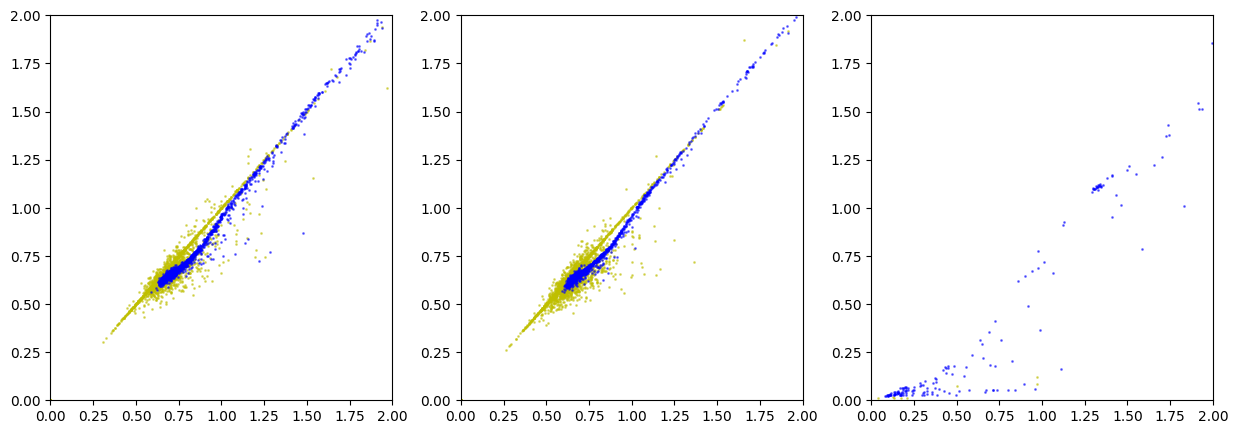

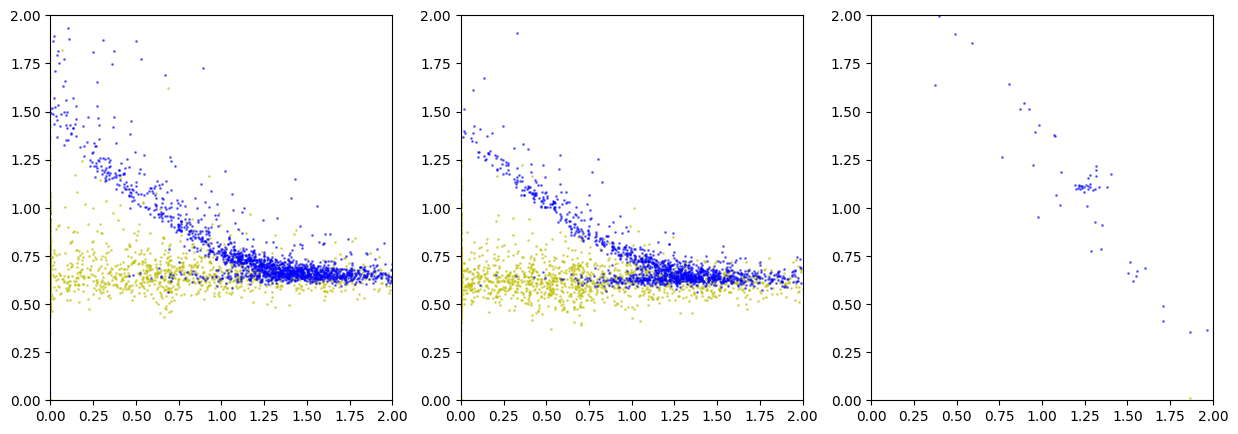

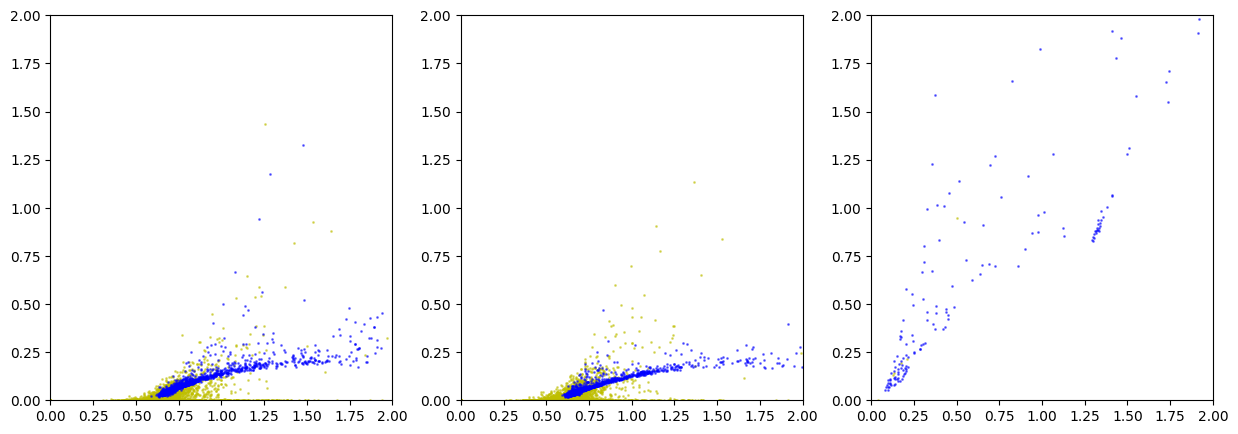

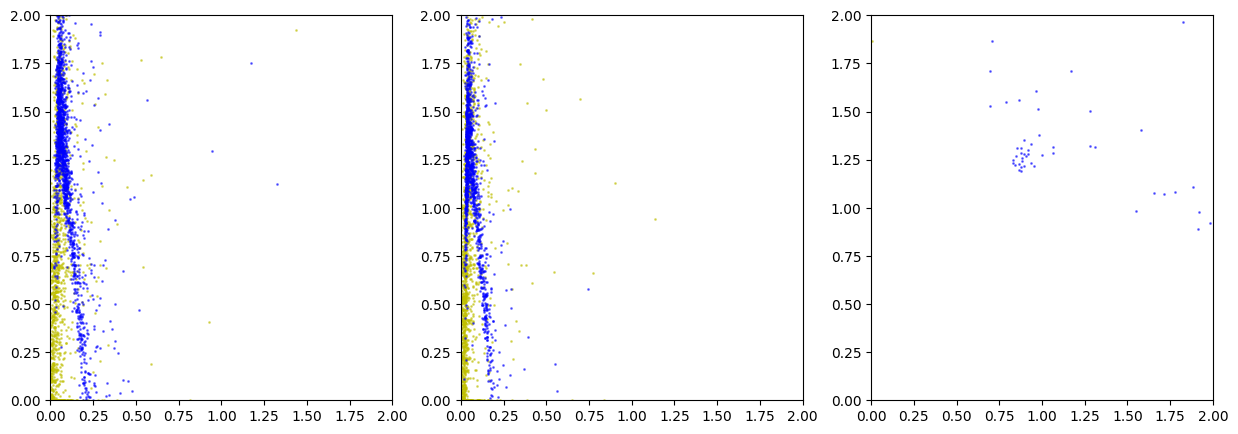

In [35]:
plot_nz_adamson_norman("mean","median")
plot_nz_adamson_norman("skew","median")
plot_nz_adamson_norman("mean","var")
plot_nz_adamson_norman("var","skew")

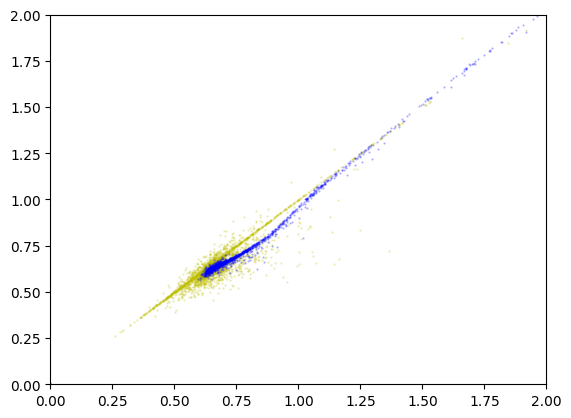

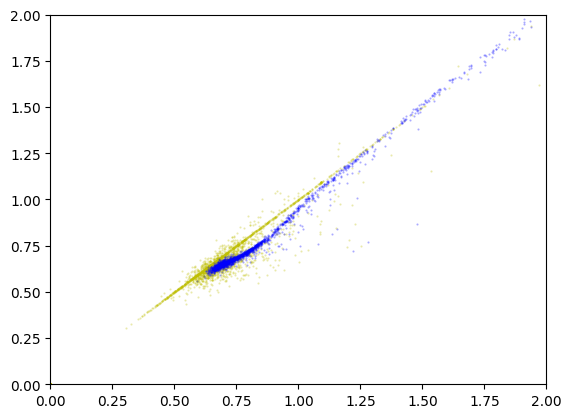

In [ ]:
plt.scatter(norman_mean_nz[norman_isdropout],norman_median_nz[norman_isdropout],s=0.3,c="y",alpha=0.3)
plt.scatter(norman_mean_nz[~norman_isdropout],norman_median_nz[~norman_isdropout],s=0.3,c="b",alpha=0.3)
plt.xlim(0,2)
plt.ylim(0,2)
plt.show()


plt.xlim(0,2)
plt.ylim(0,2)
plt.show()

### Try to fit a sigmoid curve:

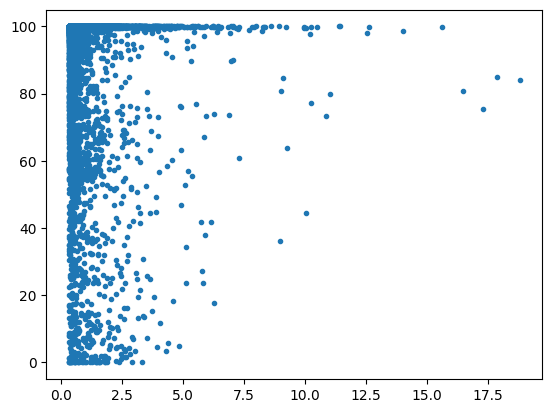

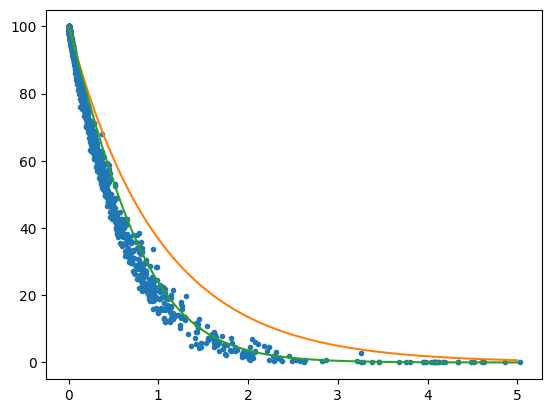

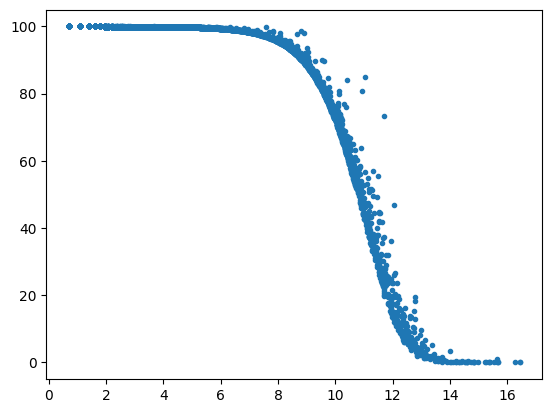

In [21]:
plt.plot(adamson_data.var["dispersions_norm"],adamson_data.var["pct_dropout_by_counts"],".") # No correlation between dropout rate and dispersion
plt.show()
fig, ax = plt.subplots()
ax.plot(norman_mean,norman_data.var["pct_dropout_by_counts"],".") # dropout rate and mean counts related through gamma dist
x = np.linspace(0.001,5,1000)
k = 1
plt.plot(x,100*k*np.exp(-k*x))
plt.plot(x,100*2*1/(1+np.exp(-(-2)*x))) # Sigmoid works surprisingly well, but why? -> sigmoid is cdf of logistic dist
ax.plot()
plt.show()
plt.plot(adamson_data.var["log1p_total_counts"],adamson_data.var["pct_dropout_by_counts"],".") # dropout rate and total counts related through logit dist (or cumul gamma?)
plt.show()

## Try Regression:

In [22]:
X_norman = np.asarray(norman_data.var[["n_cells_by_counts","log1p_mean_counts","log1p_total_counts","dispersions_norm"]])
X_norman = np.asarray(norman_data.var[["n_cells_by_counts"]])
#X_norman = np.asarray([norman_mean_non_zero]).T
y_norman = np.asarray(list(norman_isdropout),dtype=int)

X_train_norman = X_norman[~norman_isdropout]
X_test_norman = X_norman[norman_isdropout]
y_train_norman = y_norman[~norman_isdropout]
y_test_norman = y_norman[norman_isdropout]

In [23]:
# Logistic Regression:
from sklearn.linear_model import LogisticRegression
logistic_norman = LogisticRegression(random_state=1,max_iter=100).fit(X_train_norman, y_train_norman)
print(logistic_norman.predict(X_train_norman[:10,:]),y_train_norman[:10])
print(1-(sum(logistic_norman.predict(X_train_norman)^y_train_norman))/len(y_train_norman)) # 100% correctly classified
print(logistic_norman.coef_,logistic_norman.intercept_)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 1])

In [ ]:
# Fishers LDA:

np.int64(2354)

In [ ]:
clf

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
norman_data.var

,ensemble_id,ncounts,ncells,gene_name,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm
RP11-34P13.3,ENSG00000243485,29.0,29,RP11-34P13.3,False,False,False,20,0.000287,0.000287,99.971300,20.0,3.044523,True,0.000284,0.267977,0.308829
RP11-34P13.8,ENSG00000239945,10.0,10,RP11-34P13.8,False,False,False,8,0.000115,0.000115,99.988520,8.0,2.197225,True,0.000173,0.770738,2.072330
RP5-857K21.2,ENSG00000235146,3.0,3,RP5-857K21.2,False,False,False,1,0.000014,0.000014,99.998565,1.0,0.693147,True,0.000022,0.289630,0.384778
RP11-54O7.16,ENSG00000272438,41.0,41,RP11-54O7.16,False,False,False,24,0.000344,0.000344,99.965560,24.0,3.218876,True,0.000403,0.334074,0.540671
RP11-54O7.3,ENSG00000223764,976.0,937,RP11-54O7.3,False,False,False,499,0.007433,0.007406,99.283931,518.0,6.251904,True,0.007540,0.387897,0.729461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ATP6,ENSG00000198899,7457105.0,111420,MT-ATP6,True,False,False,69672,69.156204,4.250724,0.020090,4819219.0,15.388123,True,4.185784,1.497229,1.191991
MT-ND4,ENSG00000198886,11478554.0,111418,MT-ND4,True,False,False,69671,107.078133,4.682855,0.021525,7461847.0,15.825314,True,4.614620,1.729947,0.793016
MT-ND6,ENSG00000198695,539272.0,101559,MT-ND6,True,False,False,64388,5.059093,1.801560,7.602675,352548.0,12.772945,True,1.772451,0.998879,3.561519
MT-CYB,ENSG00000198727,5170633.0,111404,MT-CYB,True,False,False,69659,48.036938,3.892574,0.038745,3347502.0,15.023726,True,3.836050,1.306216,1.563828


## Discarded: Subclass of stats.rv_continuous for gamma-normal

In [ ]:
class gamma_normal_gen(stats.rv_continuous):
    "Gamma Distribution"
    def __init__(self):
        self.shapes="lamb, alpha, beta"
        self.a = 0.
    def _argcheck(self,x,lamb,alpha,beta):
        return (0<=lamb<=1) & (0<alpha<=10) & (0<beta<=10)
    def _pdf(self,x,lamb,alpha,beta):#,mu,sigma):
        return lamb*stats.gamma.pdf(x,alpha,scale=beta)#+(1-lamb)*(np.exp(-(x-mu)**2/(2*sigma**2))/np.sqrt(2.0*np.pi*sigma**2))#
    #def _shape_info(self):
    #    return [_ShapeInfo("lamb, alpha, beta", False, [(0,1),(0,10),(0,10)])]
    

In [ ]:
gn = gamma_normal_gen()#a=0.,shapes="lamb,alpha,beta")

In [ ]:
shapes = (0.5,1,0.5,0,1)
shapes = (0.5,1.0,0.5,1.0,1.0)

In [ ]:
gn.pdf(2,0.5,1.0,0.5)

AttributeError: 'gamma_normal_gen' object has no attribute '_parse_args'

In [ ]:
data = stats.gamma.rvs(1.0,1.0,size=10)

In [ ]:
stats.fit(gn,data,[(0,1),(0,3),(0,3)])

ValueError: Distribution `Distribution` is not yet supported by `scipy.stats.fit` because shape information has not been defined.

In [ ]:
stats.norm.rvs(1,1,size=10)

array([-0.07085624,  1.21153099,  1.46395751,  2.87962498,  0.57603295,
        1.94808404,  0.68883281,  2.03233699,  1.1937067 ,  1.36900526])

In [ ]:
gn.rvs(*shapes,size=10,random_state=np.random.default_rng())

/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2046: RuntimeWarning: overflow encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


ValueError: The function value at x=nan is NaN; solver cannot continue.

In [ ]:
stats.norm.pdf(1,0,2)

np.float64(0.17603266338214973)

## Maybe viable: Use optimize.minimize

In [ ]:
y_axis = adamson_data.var["log1p_mean_counts"].to_numpy()#np.linspace(0, 20, num=5_000)
pdf_y = adamson_data.var["pct_dropout_by_counts"].to_numpy()#two_gamma(y_axis, W, ALPHA1, SCALE1, ALPHA2, SCALE2) #w*g1 + (1-w)*g2

#Sample data for testing
Y = np.vstack([y_axis,pdf_y]).T[:500]

In [ ]:
dist = stats.expon
res = stats.fit(dist,y_axis)

FitParams(loc=np.float64(0.0), scale=np.float64(1.0))


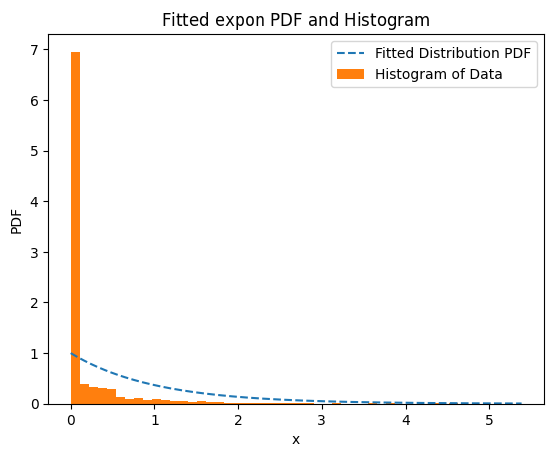

In [ ]:
res.plot()
print(res.params)

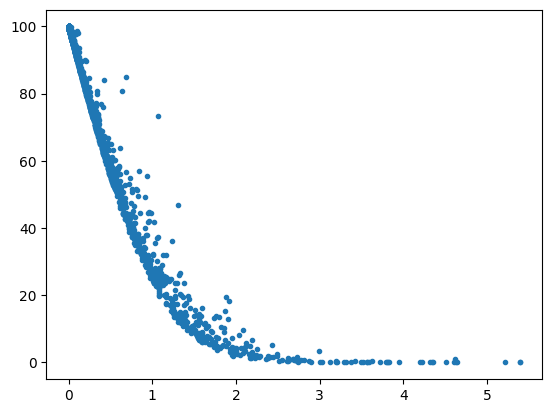

In [ ]:
plt.plot(y_axis,pdf_y,".")

In [ ]:
def gamma_normal(x, lamb, alpha, beta, mu, sigma):
    #Construct the current estimated PDF
    gamma_pdf = 100*stats.gamma.pdf(x, alpha, scale=beta)
    norm_pdf = 100*stats.norm.pdf(x,mu,scale=sigma)
    #norm_pdf = stats.norm.pdf(x,mu,sigma)
    y_pdf_estimate = lamb * gamma_pdf + (1 - lamb) * norm_pdf

    return y_pdf_estimate


In [ ]:
def gn_mle(params):
    y_pdf_estimate = gamma_normal(Y,*params)

    avg_neg_ll = -np.log(y_pdf_estimate+1e-8).mean()
    return avg_neg_ll

In [ ]:
initial_guess = [1]*5
bounds = [(0,1)]+[(0,None)]*4
results = scipy.optimize.minimize(gn_mle,x0=initial_guess,bounds=bounds)
estimated_params = (w, alpha1, scale1, alpha2, scale2) = results['x']

In [ ]:
y_pdf_fit = gamma_normal(adamson_data.var["log1p_mean_counts"][:500], *estimated_params)

In [ ]:
estimated_params

array([0.5])

(0.0, 300.0)

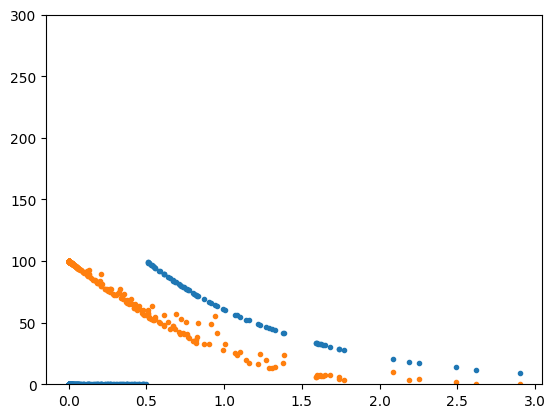

In [ ]:
fig, ax = plt.subplots()
ax.plot(y_axis[:500],y_pdf_fit,".")
ax.plot(y_axis[:500],pdf_y[:500],".")
ax.set_ylim(0,1)
#ax.plot(adamson_data.var["log1p_mean_counts"],adamson_data.var["pct_dropout_by_counts"],".")

## Other Resources:
- M3Drop: https://pmc.ncbi.nlm.nih.gov/articles/PMC6691329/
- scImpute: https://www.nature.com/articles/s41467-018-03405-7#Sec16
- MLE/EM: https://www.statlect.com/fundamentals-of-statistics/normal-distribution-maximum-likelihood
- scipy.fit: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.fit.html
- scipy.stats.rv_continuous: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.html#scipy.stats.rv_continuous
- Guide to new dists: https://docs.scipy.org/doc/scipy/dev/contributor/adding_new.html#adding-a-new-statistics-distribution
- Other peoples attempts:
    - https://stackoverflow.com/questions/78536889/how-to-implement-a-mixture-of-gamma-distributions-in-python-without-bayes
    - https://datascience.stackexchange.com/questions/131048/specifying-and-fitting-a-custom-distribution-to-data
- Logistic: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Sparsity in general: https://biocellgen-public.svi.edu.au/mig_2019_scrnaseq-workshop/handling-sparsity.html